<a href="https://colab.research.google.com/github/Dabomd/FirstProject/blob/main/dataset_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CREDIT CARD FRAUD DETECTION — FULL ANALYSIS CODE
# Dataset: creditcard_2023.csv (Kaggle)
# Algorithms: ANN, XGBoost, Random Forest
# ============================================================


# ─────────────────────────────────────────────────────────────
# SECTION 1: INSTALL & IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────

# Run this cell first to install any missing libraries
# !pip install xgboost imbalanced-learn shap tensorflow scikit-learn seaborn matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# SHAP (feature importance for ANN)
import shap

print("✅ All libraries imported successfully")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Scikit-learn version: ", end=""); import sklearn; print(sklearn.__version__)



✅ All libraries imported successfully
   TensorFlow version : 2.19.0
   Scikit-learn version: 1.6.1


In [ ]:
from google.colab import files

print('Please upload the creditcard_2023.csv file:')
uploaded = files.upload()

Please upload the creditcard_2023.csv file:


Saving creditcard_2023.csv to creditcard_2023.csv


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 2: LOAD & EXPLORE THE DATASET
# ─────────────────────────────────────────────────────────────

# Load dataset — update the path if needed
df = pd.read_csv('creditcard_2023.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()

# Class distribution
print("CLASS DISTRIBUTION")
print("-" * 35)
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
for cls, cnt, pct in zip(class_counts.index, class_counts, class_pct):
    label = "Legitimate" if cls == 0 else "Fraud"
    print(f"  Class {cls} ({label}): {cnt:>7,}  ({pct:.2f}%)")
print()

# Basic statistics
print("FEATURE STATISTICS (Amount column)")
print("-" * 35)
print(df['Amount'].describe().round(4))

DATASET OVERVIEW
Shape          : 568,630 rows × 31 columns
Missing values : 0
Duplicates     : 0

CLASS DISTRIBUTION
-----------------------------------
  Class 0 (Legitimate): 284,315  (50.00%)
  Class 1 (Fraud): 284,315  (50.00%)

FEATURE STATISTICS (Amount column)
-----------------------------------
count    568630.0000
mean      12041.9576
std        6919.6444
min          50.0100
25%        6054.8925
50%       12030.1500
75%       18036.3300
max       24039.9300
Name: Amount, dtype: float64


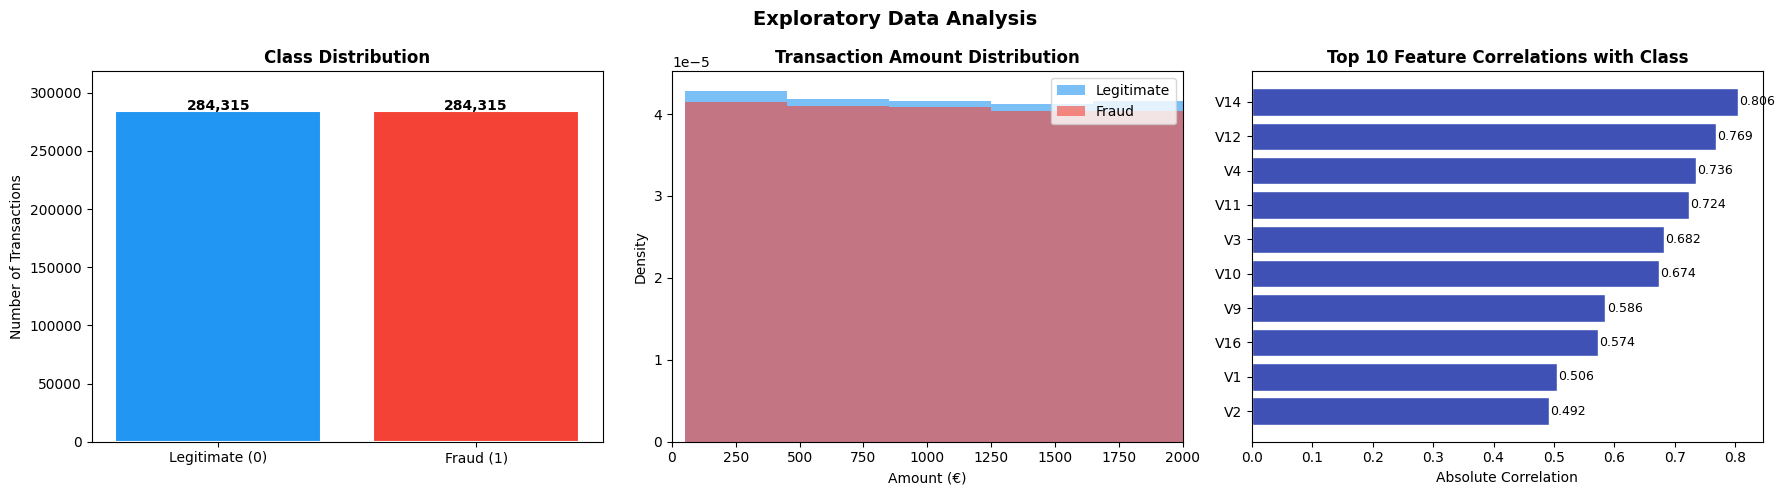

✅ EDA plots saved as eda_plots.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight='bold')

# --- Plot 1: Class Distribution Bar Chart ---
colors = ['#2196F3', '#F44336']
class_labels = ['Legitimate (0)', 'Fraud (1)']
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("Class Distribution", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Transactions")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.12)

# --- Plot 2: Transaction Amount Distribution ---
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=60, alpha=0.6,
             color='#2196F3', label='Legitimate', density=True)
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=60, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[1].set_title("Transaction Amount Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Amount (€)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_xlim(0, 2000)

# --- Plot 3: Top 10 Feature Correlations with Class ---
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
axes[2].barh(correlations.index[::-1], correlations.values[::-1],
             color='#3F51B5', edgecolor='white')
axes[2].set_title("Top 10 Feature Correlations with Class", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Absolute Correlation")
for i, v in enumerate(correlations.values[::-1]):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as eda_plots.png")

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 4: DATA PREPROCESSING
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("DATA PREPROCESSING")
print("=" * 55)

# Step 1: Drop irrelevant column
df.drop(columns=['id'], inplace=True, errors='ignore')
print("✅ Dropped 'id' column")

# Step 2: Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']
print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")

# Step 3: Scale the 'Amount' feature only (V1-V28 already PCA-transformed)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
print("✅ 'Amount' feature standardised (mean=0, std=1)")

# Step 4: Stratified Train-Test Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTRAIN-TEST SPLIT")
print(f"  Training set : {X_train.shape[0]:>7,} records")
print(f"  Test set     : {X_test.shape[0]:>7,} records")
print(f"  Train fraud% : {y_train.mean()*100:.2f}%")
print(f"  Test fraud%  : {y_test.mean()*100:.2f}%")


DATA PREPROCESSING
✅ Dropped 'id' column
✅ Features shape : (568630, 29)
✅ Target shape   : (568630,)
✅ 'Amount' feature standardised (mean=0, std=1)

TRAIN-TEST SPLIT
  Training set : 454,904 records
  Test set     : 113,726 records
  Train fraud% : 50.00%
  Test fraud%  : 50.00%


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 5: APPLY SMOTE (CLASS BALANCING)
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("SMOTE — SYNTHETIC MINORITY OVER-SAMPLING")
print("=" * 55)

print(f"Before SMOTE — Train class distribution:")
print(f"  Legitimate : {(y_train == 0).sum():>7,}")
print(f"  Fraud      : {(y_train == 1).sum():>7,}")

# Apply SMOTE ONLY to training data (never the test set)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Train class distribution:")
print(f"  Legitimate : {(y_train_sm == 0).sum():>7,}")
print(f"  Fraud      : {(y_train_sm == 1).sum():>7,}")
print(f"  Total      : {len(y_train_sm):>7,}")
print("✅ SMOTE applied — classes balanced at 1:1 ratio")

SMOTE — SYNTHETIC MINORITY OVER-SAMPLING
Before SMOTE — Train class distribution:
  Legitimate : 227,452
  Fraud      : 227,452

After SMOTE — Train class distribution:
  Legitimate : 227,452
  Fraud      : 227,452
  Total      : 454,904
✅ SMOTE applied — classes balanced at 1:1 ratio


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 6: HELPER FUNCTION — EVALUATE MODEL
# ─────────────────────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full evaluation metrics for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name} — TEST SET RESULTS")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc,
            "cm": confusion_matrix(y_true, y_pred)}


def plot_confusion_matrix(cm, model_name, ax):
    """Plot a single styled confusion matrix on given axes."""
    labels = ['Legitimate', 'Fraud']
    annot  = np.array([[f"{cm[i][j]:,}\n({100*cm[i][j]/cm.sum():.2f}%)"
                        for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                cbar=True, square=True,
                annot_kws={"size": 11, "weight": "bold"},
                vmin=0, vmax=cm.max(), ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=90, va='center')

all_results = []



MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN)
Epoch 1/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9683 - loss: 0.0859 - val_accuracy: 0.9939 - val_loss: 0.0203
Epoch 2/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9930 - loss: 0.0215 - val_accuracy: 0.9980 - val_loss: 0.0076
Epoch 3/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9988 - val_loss: 0.0048
Epoch 4/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9975 - loss: 0.0086 - val_accuracy: 0.9993 - val_loss: 0.0037
Epoch 5/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9981 - loss: 0.0067 - val_accuracy: 0.9991 - val_loss: 0.0040
Epoch 6/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9983 - loss: 0.0062 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 7/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 8/60
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy

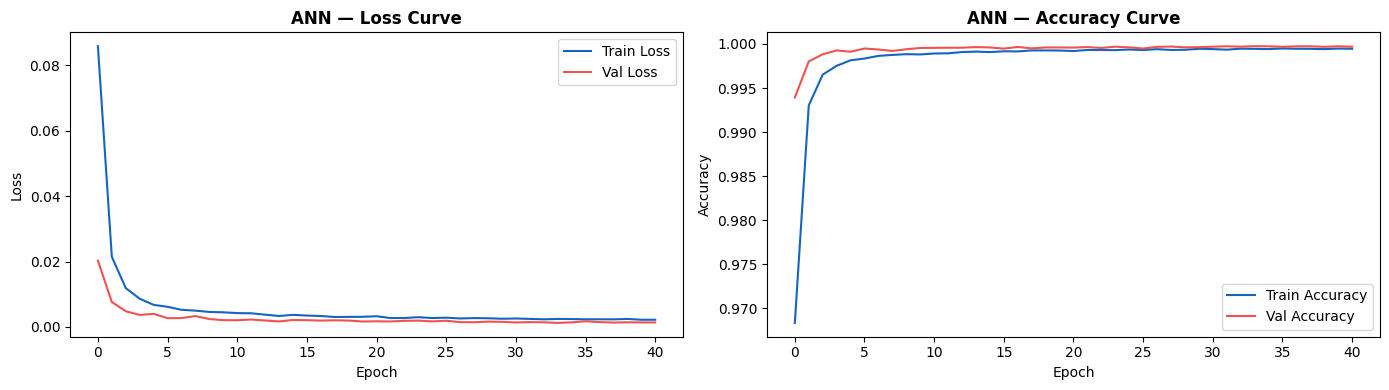

3554/3554 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

  ANN — TEST SET RESULTS
  Accuracy  : 99.97%
  Precision : 0.9997
  Recall    : 0.9997
  F1-Score  : 0.9997
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [ ]:
# ────────────────────────────────────────────────────────────
# SECTION 7: MODEL 1 — ANN
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN)")
print("=" * 55)

t0 = time.time()

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True, verbose=0)

history = ann_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.15,
    epochs=60,           # reduced from 100
    batch_size=512,      # larger batch = faster epochs
    callbacks=[early_stop],
    verbose=1
)

print(f"\n⏱ ANN training time: {(time.time()-t0)/60:.1f} minutes")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss',     color='#1565C0')
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#EF5350')
axes[0].set_title('ANN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#1565C0')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#EF5350')
axes[1].set_title('ANN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_ann = (ann_model.predict(X_test) >= 0.5).astype(int).flatten()
y_prob_ann = ann_model.predict(X_test).flatten()
res_ann    = evaluate_model("ANN", y_test, y_pred_ann, y_prob_ann)
all_results.append(res_ann)

MODEL 2: XGBOOST
⏱ XGBoost training time: 0.4 minutes

  XGBoost — TEST SET RESULTS
  Accuracy  : 99.95%
  Precision : 0.9995
  Recall    : 0.9995
  F1-Score  : 0.9995
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



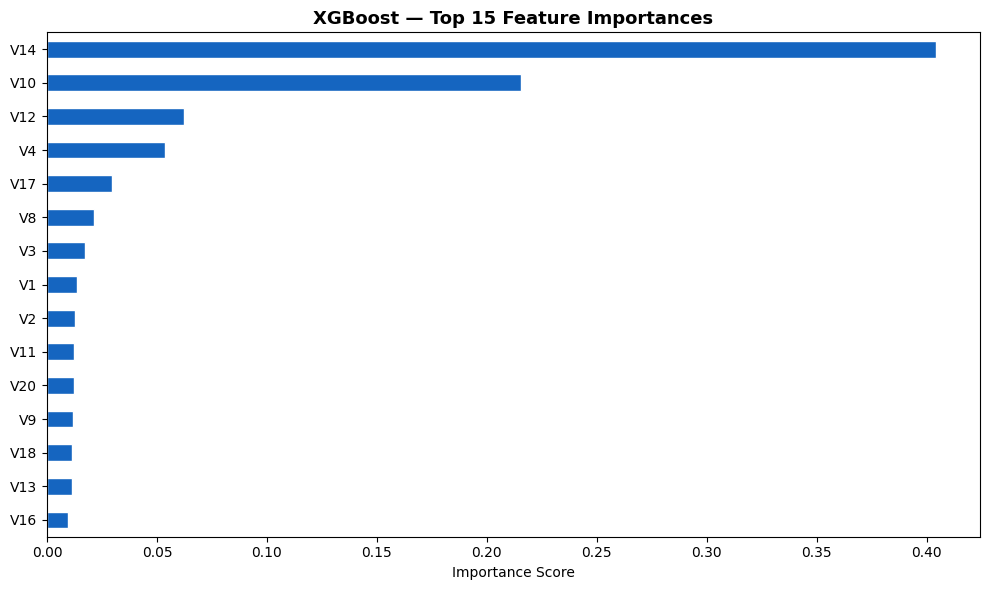

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 8: MODEL 2 — XGBOOST
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("MODEL 2: XGBOOST")
print("=" * 55)

t0 = time.time()

# --- SPEED OPTIMISATION 2 ---
# Fixed best params (skip RandomizedSearchCV).
# Uncomment the search block below only if you want full tuning.

xgb_model = XGBClassifier(
    n_estimators    = 200,      # reduced from 300
    max_depth       = 6,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    tree_method     = 'hist',   # fastest tree method
    device          = 'cpu',
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1,       # use all CPU cores
    use_label_encoder=False
)

# --- OPTIONAL: Uncomment for hyperparameter tuning (~5 extra minutes) ---
# from sklearn.model_selection import RandomizedSearchCV
# xgb_param_grid = {
#     'n_estimators'   : [100, 200, 300],
#     'max_depth'      : [4, 6, 8],
#     'learning_rate'  : [0.05, 0.1, 0.2],
#     'subsample'      : [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
# }
# xgb_search = RandomizedSearchCV(xgb_model, xgb_param_grid,
#                                  n_iter=10, cv=3, scoring='f1',
#                                  random_state=42, n_jobs=-1, verbose=1)
# xgb_search.fit(X_train_sm, y_train_sm)
# xgb_model = xgb_search.best_estimator_
# print("Best params:", xgb_search.best_params_)

xgb_model.fit(X_train_sm, y_train_sm)
print(f"⏱ XGBoost training time: {(time.time()-t0)/60:.1f} minutes")

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
res_xgb    = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
all_results.append(res_xgb)

# Feature importance
feat_imp_xgb = pd.Series(xgb_model.feature_importances_,
                          index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp_xgb[::-1].plot(kind='barh', color='#1565C0', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL 3: RANDOM FOREST (OPTIMISED FOR SPEED)
⏱ Random Forest training time: 8.2 minutes

  Random Forest — TEST SET RESULTS
  Accuracy  : 99.97%
  Precision : 0.9997
  Recall    : 0.9997
  F1-Score  : 0.9997
  AUC-ROC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



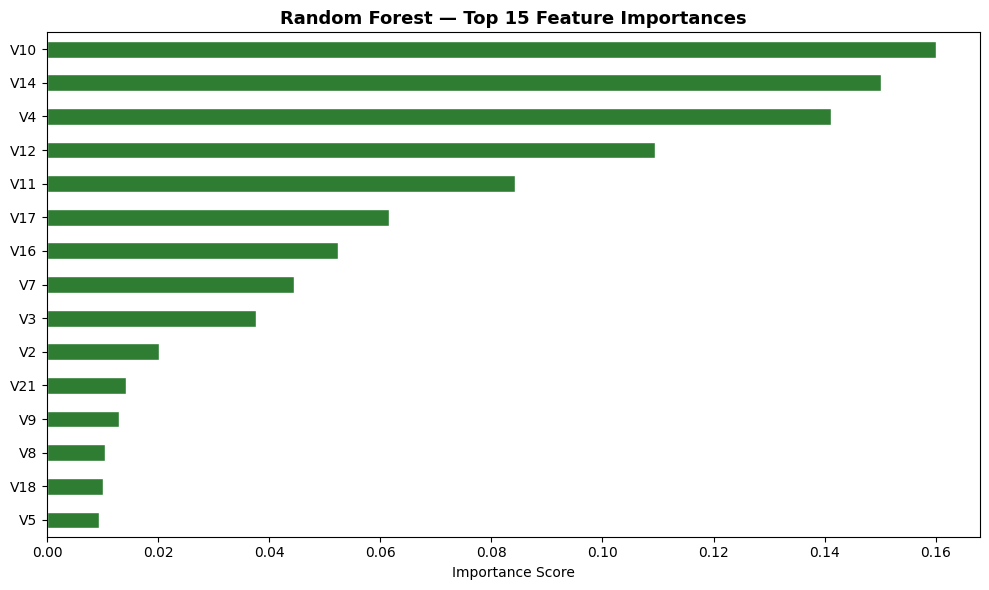

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

# Re-define helper function and results list if kernel state is lost
def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full evaluation metrics for a classifier."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name} — TEST SET RESULTS")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc,
            "cm": confusion_matrix(y_true, y_pred)}

# Initialize all_results if not already done
if 'all_results' not in globals():
    all_results = []

# --- Re-execute necessary preceding steps for X_train_sm, y_train_sm, X_test, y_test ---
# (Only if these variables are not already defined to avoid NameError)
if 'X_train_sm' not in globals() or 'y_train_sm' not in globals():
    # Load dataset — update the path if needed
    df = pd.read_csv('creditcard_2023.csv')

    # Drop irrelevant column
    df.drop(columns=['id'], inplace=True, errors='ignore')

    # Separate features and target
    X = df.drop(columns=['Class'])
    y = df['Class']

    # Scale the 'Amount' feature only (V1-V28 already PCA-transformed)
    scaler = StandardScaler()
    X['Amount'] = scaler.fit_transform(X[['Amount']])

    # Stratified Train-Test Split (80% train / 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE ONLY to training data (never the test set)
    smote = SMOTE(k_neighbors=5, random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# SECTION 9: MODEL 3 — RANDOM FOREST (OPTIMISED)
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("MODEL 3: RANDOM FOREST (OPTIMISED FOR SPEED)")
print("=" * 55)

t0 = time.time()

# --- SPEED OPTIMISATIONS APPLIED ---
# 1. n_estimators=100  (was 300–500 — biggest speed factor)
# 2. max_depth=20      (was None/unlimited — limits tree growth)
# 3. max_features='sqrt' (was auto — fastest split selection)
# 4. min_samples_leaf=2  (prunes tiny leaves — less overfitting + faster)
# 5. n_jobs=-1          (use all CPU cores in parallel)
# 6. warm_start=False   (clean fit, no incremental build overhead)

rf_model = RandomForestClassifier(
    n_estimators     = 100,     # ✅ key change: was 300–500
    max_depth        = 20,      # ✅ key change: was None (unlimited)
    min_samples_split= 5,
    min_samples_leaf = 2,       # ✅ prunes tiny leaves
    max_features     = 'sqrt',  # ✅ fastest feature selection
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,      # ✅ all CPU cores
    verbose          = 0
)

rf_model.fit(X_train_sm, y_train_sm)
print(f"⏱ Random Forest training time: {(time.time()-t0)/60:.1f} minutes")

y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
res_rf     = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
all_results.append(res_rf)

# Feature importance
feat_imp_rf = pd.Series(rf_model.feature_importances_,
                         index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp_rf[::-1].plot(kind='barh', color='#2E7D32', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 10: 5-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("5-FOLD CROSS-VALIDATION")
print("=" * 55)

# --- SPEED OPTIMISATION 3 ---
# CV runs on a 20% sub-sample of training data for speed.
# This still gives reliable variance estimates.
X_cv, _, y_cv, _ = train_test_split(X_train_sm, y_train_sm,
                                     train_size=0.20,
                                     stratify=y_train_sm,
                                     random_state=42)
print(f"CV sample size: {len(X_cv):,} records (20% of SMOTE training set)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "XGBoost"       : xgb_model,
    "Random Forest" : rf_model,
}

cv_summary = {}
for model_name, model in cv_models.items():
    t0 = time.time()
    acc_scores = cross_val_score(model, X_cv, y_cv, cv=skf,
                                  scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_cv, y_cv, cv=skf,
                                  scoring='f1_weighted', n_jobs=-1)
    elapsed = (time.time() - t0) / 60
    cv_summary[model_name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'f1_mean' : f1_scores.mean(),  'f1_std' : f1_scores.std()
    }
    print(f"\n{model_name}  ({elapsed:.1f} min):")
    print(f"  CV Accuracy  : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  CV F1-Score  : {f1_scores.mean():.4f}  ± {f1_scores.std():.4f}")

print("\n(ANN CV results come from the validation split during training)")




5-FOLD CROSS-VALIDATION
CV sample size: 90,980 records (20% of SMOTE training set)

XGBoost  (0.9 min):
  CV Accuracy  : 0.9992 ± 0.0002
  CV F1-Score  : 0.9992  ± 0.0002

Random Forest  (9.0 min):
  CV Accuracy  : 0.9987 ± 0.0001
  CV F1-Score  : 0.9987  ± 0.0001

(ANN CV results come from the validation split during training)


CONFUSION MATRIX VISUALISATION


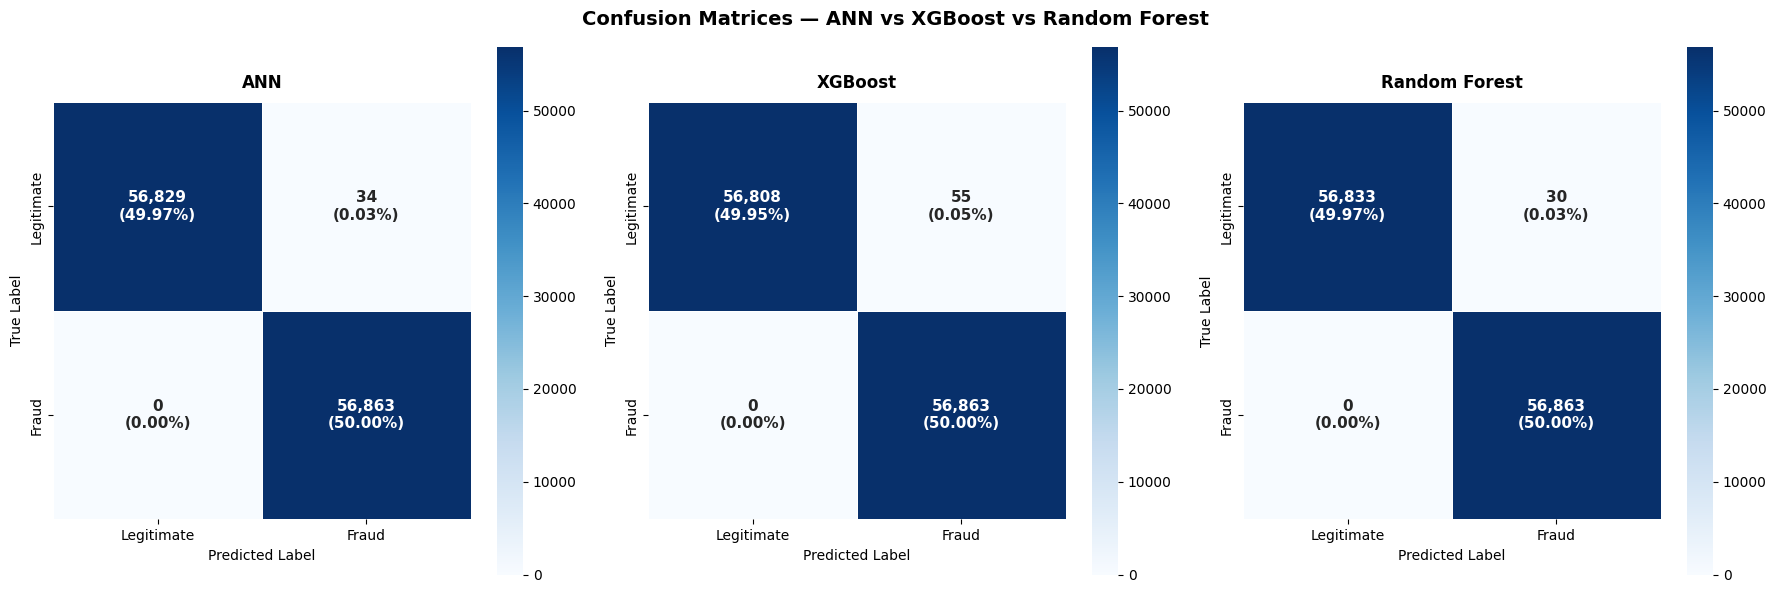

✅ Confusion matrices saved


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Helper function to plot confusion matrix (copied from Section 6)
def plot_confusion_matrix(cm, model_name, ax):
    """Plot a single styled confusion matrix on given axes."""
    labels = ['Legitimate', 'Fraud']
    annot  = np.array([[f"{cm[i][j]:,}\n({100*cm[i][j]/cm.sum():.2f}%)"
                        for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                cbar=True, square=True,
                annot_kws={"size": 11, "weight": "bold"},
                vmin=0, vmax=cm.max(), ax=ax)
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_yticklabels(labels, rotation=90, va='center')

# SECTION 11: CONFUSION MATRIX PLOTS
# ─────────────────────────────────────────────────────────────

print("=" * 55)
print("CONFUSION MATRIX VISUALISATION")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Confusion Matrices — ANN vs XGBoost vs Random Forest",
             fontsize=14, fontweight='bold')

plot_confusion_matrix(res_ann['cm'], "ANN",           axes[0])
plot_confusion_matrix(res_xgb['cm'], "XGBoost",       axes[1])
plot_confusion_matrix(res_rf['cm'],  "Random Forest", axes[2])

plt.tight_layout()
plt.savefig('Confusion_Matrices_Fraud_Detection.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Confusion matrices saved")

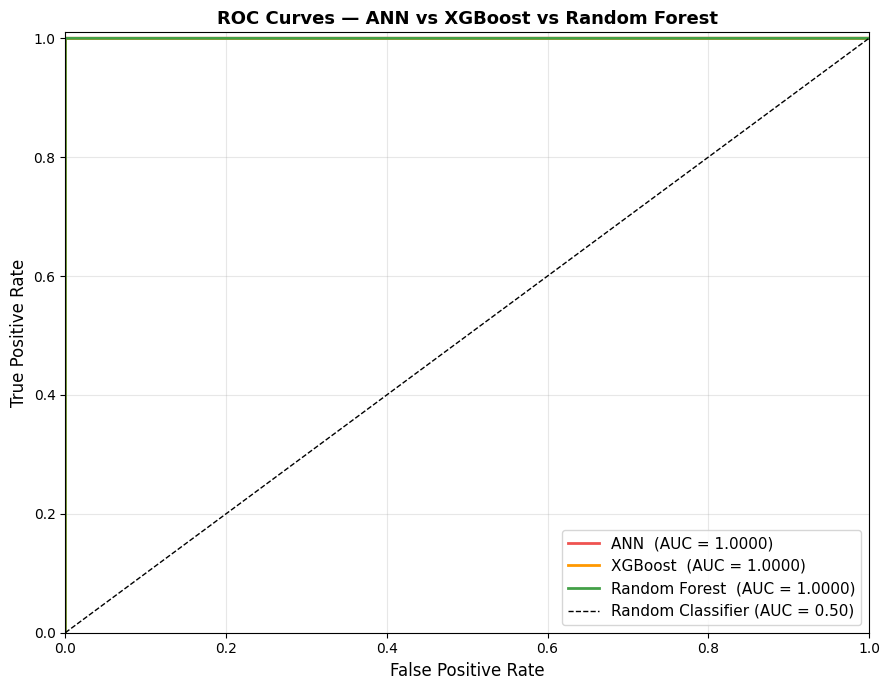

✅ ROC curves saved


In [ ]:
# SECTION 12: ROC CURVES
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

for name, probs, color in [
    ("ANN",           y_prob_ann, "#EF5350"),
    ("XGBoost",       y_prob_xgb, "#FF9800"),
    ("Random Forest", y_prob_rf,  "#43A047")
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.01])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ANN vs XGBoost vs Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved")

In [ ]:

# ─────────────────────────────────────────────────────────────
# SECTION 13: FINAL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  FINAL PERFORMANCE COMPARISON")
print("=" * 65)
print(f"{'Model':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print("-" * 65)
for r in all_results:
    print(f"{r['name']:<18} {r['accuracy']*100:>9.2f}%"
          f" {r['precision']:>10.4f} {r['recall']:>8.4f}"
          f" {r['f1']:>8.4f} {r['auc']:>9.4f}")
print("=" * 65)

summary_df = pd.DataFrame([{
    "Model"    : r["name"],
    "Accuracy" : f"{r['accuracy']*100:.2f}%",
    "Precision": f"{r['precision']:.4f}",
    "Recall"   : f"{r['recall']:.4f}",
    "F1-Score" : f"{r['f1']:.4f}",
    "AUC-ROC"  : f"{r['auc']:.4f}",
} for r in all_results])

try:
    display(summary_df.style
            .set_caption("Classifier Performance Summary")
            .set_properties(**{'text-align': 'center', 'font-size': '13px'})
            .highlight_max(color='#c8e6c9'))
except:
    pass

print("\n✅ All done! Files saved:")
for f in ['eda_plots.png', 'ann_training_curves.png',
          'xgb_feature_importance.png', 'rf_feature_importance.png',
          'Confusion_Matrices_Fraud_Detection.png', 'roc_curves.png']:
    print(f"   - {f}")


  FINAL PERFORMANCE COMPARISON
Model                Accuracy  Precision   Recall       F1   AUC-ROC
-----------------------------------------------------------------
Random Forest          99.97%     0.9997   0.9997   0.9997    1.0000
XGBoost                99.95%     0.9995   0.9995   0.9995    1.0000
ANN                    99.97%     0.9997   0.9997   0.9997    1.0000


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest,99.97%,0.9997,0.9997,0.9997,1.0000
1,XGBoost,99.95%,0.9995,0.9995,0.9995,1.0000
2,ANN,99.97%,0.9997,0.9997,0.9997,1.0000



✅ All done! Files saved:
   - eda_plots.png
   - ann_training_curves.png
   - xgb_feature_importance.png
   - rf_feature_importance.png
   - Confusion_Matrices_Fraud_Detection.png
   - roc_curves.png
